# ⚛️ qAIR-vNext **v44** — the whole project, end to end

One notebook covering every stage: cache → data → model → sanity checks →
training → evaluation → **verification** → baselines → ablations →
visualisation.

Capped at **800 train / 200 validation** so the full loop runs in about
an hour instead of a day. That is enough to answer *"does the system
work?"* — it is **not** enough to produce a reportable accuracy number
(200 validation examples ⇒ standard error ≈ 3.1 points).

---

## ⚠️ Read this before trusting any number below

A v44 audit found that the three mechanisms making up this project's
research contribution — the **quantum circuit**, **multi-hypothesis
superposition**, and **Born-rule collapse** — were *all provably inert*,
while the model reported a plausible-looking 33.7%.

| # | Defect | Evidence |
|---|---|---|
| F1 | Circuit ignored its input — `Hadamard` prepares \|+⟩, an X-eigenstate, and `AngleEmbedding` defaults to RX ⇒ global phase only | output std across inputs = **0.000e+00** |
| F2 | Reasoner collapsed to a constant fixed point | pairwise cos → **1.000000**, input-independent |
| F3 | Prediction unchanged under *every* corruption of `H` | zeros / noise / shuffled / other question ⇒ all **294/869** |
| F4 | A third of cached hypotheses were template noise, misaligned to options | **33.1%** fallbacks; `argmax diag(H·O)` = 0.267 = chance |
| F5 | The question was never encoded | +**12.6 pts** once it was (0.3585 → 0.4849) |

**Accuracy could not have revealed any of these.** That is why
[section 9](#9) exists and why it matters more than the accuracy number.

**Every pre-v44 quantum/ablation result is void.** Do not compare
anything here against older notebooks.

---

### Cost warning

- **§10 baselines** — the direct-LLM arm runs the LLM over the validation
  set. Minutes.
- **§11 ablation grid** — 8 configs × 5 seeds = **40 training runs**.
  Days on CPU. Gated behind a flag; leave it off for a first pass.

Everything else runs comfortably.

<a id="1"></a>
## 1. Environment

### 1a. Run from the repo root

Every `from models…` / `from training…` import and every relative path in
`config.py` (`./cache`, `./ckpt`) assumes the repo root is the working
directory. Jupyter defaults the kernel cwd to the notebook's own folder.

In [10]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working directory:", os.getcwd())
assert os.path.exists("config.py"), (
    "Not at the repo root -- adjust the os.chdir(...) above manually, "
    r"e.g. os.chdir(r'D:\WORK\Research\qAIR-CSE499B')"
)

Working directory: d:\WORK\Research\qAIR-CSE499B


### 1b. Force Hugging Face offline

Qwen2.5-0.5B-Instruct and the MiniLM encoder are already cached locally.
Without this, `huggingface_hub` makes a network round-trip on every load
to revalidate them — and on this machine that request hangs indefinitely
(the process sits at 0% CPU, blocked on I/O, rather than failing fast).

In [11]:
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"
print("HF_HUB_OFFLINE:", os.environ["HF_HUB_OFFLINE"])

HF_HUB_OFFLINE: 1


### 1c. Imports, seed, device

`set_seed` existed for this project's entire history and was **never
called from any entry point**, so no run was ever reproducible —
`collate_fn` draws a fresh `randperm` per batch, dropout is live, and
generation samples. It is wired into every entry point now, and here.

In [12]:
from functools import partial

import torch
from torch.utils.data import DataLoader

from config import (
    CACHE_DIR, CKPT_DIR, PATIENCE, PERSISTENT_STEPS, N_QUBITS,
    BATCH_SIZE, WEIGHT_DECAY, SEED, EMBEDDING_DIM as DIM, resolve_device,
)
from training.seed import set_seed, seeded_generator
from training.dataset import QAIRDataset, collate_fn
from training.train import Trainer
from training.checkpoint import load_or_resume
from training.evaluate import evaluate
from models.full_model import QAIRvNext

set_seed(SEED)
device = resolve_device()

print("device        :", device)
print("embedding dim :", DIM)
print("n_qubits      :", N_QUBITS)

[SEED] Set to 42 (deterministic=False)
device        : cpu
embedding dim : 384
n_qubits      : 6


<a id="2"></a>
## 2. Run configuration

`TRAIN_SAMPLES` / `VAL_SAMPLES` are the important knobs.

> **These caps must stay consistent everywhere.** A cache built with
> `max_samples` is stored `complete=False` *by design*, so a later full
> build can resume and finish the split. The consequence: passing
> `max_samples=None` against a capped cache does **not** read 800
> samples — it starts generating the other 2,570. Every dataset call in
> this notebook therefore passes the caps explicitly.

In [13]:
RUN_NAME = "qair_v44"

TRAIN_SAMPLES = 800     # cap -- must match how the cache was built
VAL_SAMPLES = 200

EPOCHS = 12             # 800 samples converges fast; 30 buys little here
persistent_steps = PERSISTENT_STEPS
n_qubits = N_QUBITS

# The validator-feedback pass runs the reasoner AND the quantum layer
# twice per forward. The CPU-bound circuit dominates, so turning this off
# roughly halves epoch time while iterating.
VALIDATOR_FEEDBACK = True

print(f"train/val  : {TRAIN_SAMPLES}/{VAL_SAMPLES}")
print(f"epochs     : {EPOCHS}   patience={PATIENCE}")
print(f"steps      : {persistent_steps}   n_qubits={n_qubits}")
print(f"batch      : {BATCH_SIZE}   wd={WEIGHT_DECAY}   seed={SEED}")

train/val  : 800/200
epochs     : 12   patience=5
steps      : 3   n_qubits=6
batch      : 16   wd=0.02   seed=42


<a id="3"></a>
## 3. Cache

The slow one-time step: for every question the LLM writes one hypothesis
per answer option, then everything is embedded and cached.

**Build it from a terminal, not from here** — it takes ~1.5 h for these
caps on CPU and a notebook is a poor place to host a long job:

```bash
python scripts/build_cache.py --splits train validation --limit 800 200
```

It is resumable (autosaves every 50 samples), saves are atomic
(temp-file + `fsync` + rename), and a lock file stops a second build from
racing the first. The cell below only **loads** what that produced.

Since v44 each hypothesis comes from **its own completion**, one per
`(question, option)` pair. Splitting a single free-form completion on
newlines never guaranteed line *k* described option *k*, and the
resulting misalignment was silent — it is what drove `argmax diag(H·O)`
down to chance.

In [14]:
train_ds = QAIRDataset(split="train", max_samples=TRAIN_SAMPLES, cache_dir=CACHE_DIR)
val_ds = QAIRDataset(split="validation", max_samples=VAL_SAMPLES, cache_dir=CACHE_DIR)

print(f"\nTrain samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")

assert len(train_ds) > 0 and len(val_ds) > 0, "Empty dataset -- build the cache first."

[CACHE FOUND] ./cache\arc_train.pt
[CACHE LOADED] 800 samples (complete=False, version=33)
[CACHE TRUNCATED TO max_samples] 800 samples
[CACHE QUALITY train] fallback hypotheses 0/3200 = 0.0%   fully-fallback samples 0/800
[CACHE FOUND] ./cache\arc_validation.pt
[CACHE LOADED] 200 samples (complete=False, version=33)
[CACHE TRUNCATED TO max_samples] 200 samples
[CACHE QUALITY validation] fallback hypotheses 1/798 = 0.1%   fully-fallback samples 0/200

Train samples: 800
Val samples:   200


### 3b. Inspect one sample

Check the fallback flags. A fallback carries **no information** about
which option is correct — before v44 these were 33% of all hypotheses and
the template embedded the option text verbatim, making noise maximally
similar to its own option, which is exactly the signal the selector keys
on. Post-fix this should read 0%.

In [15]:
s = train_ds[0]

print("Question:", s["question"])
print()
flags = s.get("is_fallback", torch.zeros(len(s["hypotheses"]), dtype=torch.bool))
for i, (h, o) in enumerate(zip(s["hypotheses"], s["options"])):
    mark = "*" if i == s["y"] else " "
    fb = "  [FALLBACK]" if bool(flags[i]) else ""
    print(f" {mark}[{i}] OPT: {o}{fb}")
    print(f"      HYP: {h}")

print()
print("Q:", tuple(s["Q"].shape), " H:", tuple(s["H"].shape), " O:", tuple(s["O"].shape))
print("correct index y:", s["y"])

Question: George wants to warm his hands quickly by rubbing them. Which skin surface will produce the most heat?

 *[0] OPT: dry palms
      HYP: The mechanism for producing the most heat from Rubbing Dry Palms involves friction between the palm's surface and sweat glands, which generates heat through metabolic reactions.
  [1] OPT: wet palms
      HYP: The mechanism for producing the most heat from rubbing wet palms involves a rapid exchange of heat between the palm's surface and the surrounding air, leading to a significant increase in body temperature due to the exothermic reaction of sweat evaporating into the air, causing evaporation and release of heat.
  [2] OPT: palms covered with oil
      HYP: The palms covered with oil have a higher surface area relative to their volume compared to bare hands, allowing for greater heat transfer due to increased friction and turbulence on oil-covered surfaces, thus producing more heat quickly.
  [3] OPT: palms covered with lotion
      HYP: T

<a id="4"></a>
## 4. DataLoaders

`collate_fn` zero-pads ragged option/hypothesis counts (ARC has a few 3-
and 5-option questions) and emits `H_mask`/`O_mask`. Those masks were
computed and then **never passed to the model**, so padded options took
part in every reduction and could be returned as the prediction. They are
threaded end to end now.

In [16]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    generator=seeded_generator(SEED),      # batch ORDER reproducible too
    collate_fn=partial(collate_fn, shuffle_options=True),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=partial(collate_fn, shuffle_options=False),
)

print(f"train batches/epoch: {len(train_loader)}")
print(f"val batches:         {len(val_loader)}")

batch = next(iter(train_loader))
print()
for k, v in batch.items():
    print(f"  {k:12s} {tuple(v.shape)}  {v.dtype}")

train batches/epoch: 50
val batches:         13

  H            (16, 4, 384)  torch.float32
  O            (16, 4, 384)  torch.float32
  Q            (16, 384)  torch.float32
  H_mask       (16, 4)  torch.bool
  O_mask       (16, 4)  torch.bool
  is_fallback  (16, 4)  torch.bool
  y            (16,)  torch.int64


<a id="5"></a>
## 5. Model

```
H ─▶ PersistentReasoner ─▶ Quantum/Classical layer ─▶ Validator ─┐
                                    │                            │
Q,O ────────────────────────────────┼──▶ EnergyAnswerSelector    │ potential
                                    ▼                            │ (closed loop)
                              EnergyFusion ─▶ CollapseController ─┘
                                    ▼
                    marginalise over hypotheses ─▶ scores
```

`backend` selects what occupies the quantum slot: `"quantum"` (PennyLane
circuit), `"classical_control"` (parameter-matched MLP — the control that
makes a quantum claim falsifiable), or `"none"`.

In [17]:
model = QAIRvNext(
    dim=DIM,
    use_quantum=True,
    use_validator=True,
    persistent_steps=persistent_steps,
    n_qubits=n_qubits,
    use_question=True,          # F5 fix -- worth +12.6 pts on a probe
    validator_feedback=VALIDATOR_FEEDBACK,
    verbose=True,
).to(device)

total = sum(p.numel() for p in model.parameters())
circuit = sum(p.numel() for p in model.quantum.quantum.parameters()) \
    if hasattr(model, "quantum") and hasattr(model.quantum, "quantum") else 0

print(f"\ntotal parameters : {total:,}")
print(f"quantum circuit  : {circuit:,}  ({100*circuit/total:.4f}% of the model)")
print(f"backend          : {model.backend}")
print(f"device           : {next(model.parameters()).device}")

[QuantumEvolutionLayer] total parameters: 1,120,573 (circuit weights: 54)

total parameters : 10,578,677
quantum circuit  : 54  (0.0005% of the model)
backend          : quantum
device           : cpu


<a id="6"></a>
## 6. Sanity checks — *before* spending an hour training

Each of these targets a specific defect the audit found. Running them
first means a broken build fails in seconds rather than after training.

In [18]:
import torch.nn.functional as F

ok = True

# ---- F1: does the circuit respond to its input at all? ----------------
if model.backend == "quantum":
    with torch.no_grad():
        qa, _ = model.quantum(torch.randn(1, 4, DIM, device=device) * 0.05)
        qb, _ = model.quantum(torch.randn(1, 4, DIM, device=device) * 0.05)
    delta = (qa - qb).abs().max().item()
    good = delta > 1e-6
    ok &= good
    print(f"[F1] circuit sensitivity to input : {delta:.4e}  "
          f"{'PASS' if good else 'FAIL - circuit is a constant!'}")

# ---- F2: does the reasoner keep hypotheses distinct? ------------------
def pairwise(M):
    M = F.normalize(M, dim=-1)
    S = M @ M.transpose(1, 2)
    k = M.shape[1]
    return ((S.sum((1, 2)) - S.diagonal(dim1=1, dim2=2).sum(1)) / (k * k - k)).mean().item()

Hin = torch.stack([train_ds[i]["H"] for i in range(32)]).float().to(device)
with torch.no_grad():
    Hout = model.reasoner(Hin)[0]
before, after = pairwise(Hin), pairwise(Hout)
good = after < 0.99
ok &= good
print(f"[F2] pairwise cos  in={before:.4f} -> out={after:.4f}          "
      f"{'PASS' if good else 'FAIL - hypotheses collapsed'}")
print(f"     dt={torch.sigmoid(model.reasoner.dt).item():.4f} (intended 0.10)  "
      f"decay={torch.sigmoid(model.reasoner.memory_decay).item():.4f} (0.80)")

# ---- masks: padded slots must not influence real scores --------------
# ARC is almost all 4-option, so a random batch often contains no padding
# at all and the test would pass vacuously. Append a synthetic 3-option
# sample so there is guaranteed padding to poison.
sb = next(iter(val_loader))
H, O, Q = sb["H"].to(device), sb["O"].to(device), sb["Q"].to(device)
Hm, Om = sb["H_mask"].to(device), sb["O_mask"].to(device)
y = sb["y"].to(device)

if Om.all():
    Om = torch.cat([Om, Om[:1].clone()], 0);  Om[-1, -1] = False
    Hm = torch.cat([Hm, Hm[:1].clone()], 0);  Hm[-1, -1] = False
    H = torch.cat([H, H[:1]], 0); O = torch.cat([O, O[:1]], 0)
    Q = torch.cat([Q, Q[:1]], 0)
    # y MUST grow with the batch, or the validator's label scatter gets
    # arange(17) against y of length 16. Label 0 for the synthetic row:
    # we masked the LAST option and index 0 is always real, so the target
    # can never land on a padded slot -- which would give the true class
    # a -inf logit and a non-finite loss.
    y = torch.cat([y, torch.zeros(1, dtype=y.dtype, device=y.device)], 0)
    print("[mask] batch had no padding; appended a synthetic 3-option sample")

model.eval()
with torch.no_grad():
    s1 = model(H, O, Q=Q, H_mask=Hm, O_mask=Om)["scores"]
    O2 = O.clone(); O2[~Om] = torch.randn_like(O2[~Om]) * 99      # poison padding
    s2 = model(H, O2, Q=Q, H_mask=Hm, O_mask=Om)["scores"]

delta = (s1 - s2).masked_select(Om).abs().max().item()
picked_pad = (~Om.gather(1, s1.argmax(1, keepdim=True))).any().item()
good = delta < 1e-5 and not picked_pad
ok &= good
print(f"[mask] {int((~Om).sum())} padded slots; poisoning them moves real "
      f"scores by {delta:.2e}; padded option predicted: {picked_pad}  "
      f"{'PASS' if good else 'FAIL - padding leaks'}")

# ---- gradients flow ---------------------------------------------------
from training.losses import compute_loss
model.train()
out = model(H, O, Q=Q, y=y, H_mask=Hm, O_mask=Om)
loss = compute_loss(out, y)
loss.backward()
gnorm = sum(p.grad.norm().item() ** 2 for p in model.parameters()
            if p.grad is not None) ** 0.5
model.zero_grad(set_to_none=True)
good = bool(torch.isfinite(loss)) and gnorm > 0
ok &= good
print(f"[grad] loss={loss.item():.4f}  |grad|={gnorm:.3f}  "
      f"{'PASS' if good else 'FAIL'}")

print("\n" + ("ALL SANITY CHECKS PASSED" if ok else "*** SANITY CHECKS FAILED ***"))

[F1] circuit sensitivity to input : 3.2995e+00  PASS
[F2] pairwise cos  in=0.6367 -> out=0.6356          PASS
     dt=0.1000 (intended 0.10)  decay=0.8000 (0.80)
[mask] batch had no padding; appended a synthetic 3-option sample
[mask] 1 padded slots; poisoning them moves real scores by 0.00e+00; padded option predicted: False  PASS
[grad] loss=1.8379  |grad|=0.607  PASS

ALL SANITY CHECKS PASSED


<a id="7"></a>
## 7. Train

Interrupting is safe — a `_latest.pt` checkpoint is written every epoch,
so re-running the Trainer cell resumes from the last completed epoch.

**Watch `Pairwise Cos` and `H Cos`, not just accuracy.** They measure
whether hypotheses stay distinguishable after reasoning. Near 1.0 means
they have merged, the collapse distribution is uniform by construction,
and the multi-hypothesis mechanism is inert — precisely what happened
pre-v44 while accuracy read a respectable 33.7%. The trainer prints a
`[COLLAPSE WARNING]` above 0.99 and names which failure mode it is:

| | |
|---|---|
| `h_cos ≈ 1` and `pairwise_cos ≈ 1` | the **reasoner** merged the hypotheses — architectural |
| `h_cos < 1` but `pairwise_cos ≈ 1` | hypotheses stay distinct but the **selector ignores them** — a low-signal cache; regenerate, don't tune |

In [19]:
trainer = Trainer(
    model=model, train_loader=train_loader, val_loader=val_loader,
    device=device, ckpt_dir=CKPT_DIR, name=RUN_NAME,
    weight_decay=WEIGHT_DECAY, verbose=True,
)

start_epoch, best_acc, _ = load_or_resume(trainer, CKPT_DIR, RUN_NAME, EPOCHS)
print(f"\nstarting from epoch {start_epoch}/{EPOCHS}  (best so far {best_acc:.4f})")


Checkpoint Search:
./ckpt\qair_v44_latest.pt
Exists: False

starting from epoch 0/12  (best so far 0.0000)


In [20]:
history = trainer.train(
    epochs=EPOCHS, start_epoch=start_epoch,
    best_acc=best_acc, patience=PATIENCE,
)

[qair_v44] Epoch 1/12: 100%|██████████| 50/50 [01:01<00:00,  1.24s/it, loss=1.6878]



[qair_v44] Epoch 1/12   LR 0.000491
Train Loss    : 1.8260
Val Acc       : 0.3450
Entropy       : 1.3831
Diversity     : 0.000829
Collapse Peak : 0.2586
Pairwise Cos  : 0.9999 (energy rows)
H Cos         : 0.9615 (hypothesis vectors)
energy_alpha=0.4983 validator_alpha=0.4980 dt=0.0997 anchor=0.5001
[qair_v44][COLLAPSE WARNING] pairwise_cos=0.999861 -- the multi-hypothesis mechanism is inert and accuracy here reflects option priors only. Diagnosis: the hypotheses are still distinct (h_cos=0.9615) but the SELECTOR is ignoring them -- this is what a low-signal cache looks like. Check the fallback rate printed at load and regenerate; do not tune the model. Confirm with evaluation/input_ablation.py.
[qair_v44][BEST] 0.3450


[qair_v44] Epoch 2/12: 100%|██████████| 50/50 [01:02<00:00,  1.25s/it, loss=1.6819]



[qair_v44] Epoch 2/12   LR 0.000467
Train Loss    : 1.6774
Val Acc       : 0.3250
Entropy       : 1.3732
Diversity     : 0.025638
Collapse Peak : 0.2869
Pairwise Cos  : 0.9942 (energy rows)
H Cos         : 0.7896 (hypothesis vectors)
energy_alpha=0.4957 validator_alpha=0.4965 dt=0.0989 anchor=0.5024
[qair_v44][COLLAPSE WARNING] pairwise_cos=0.994171 -- the multi-hypothesis mechanism is inert and accuracy here reflects option priors only. Diagnosis: the hypotheses are still distinct (h_cos=0.7896) but the SELECTOR is ignoring them -- this is what a low-signal cache looks like. Check the fallback rate printed at load and regenerate; do not tune the model. Confirm with evaluation/input_ablation.py.


[qair_v44] Epoch 3/12: 100%|██████████| 50/50 [01:02<00:00,  1.25s/it, loss=1.6031]


...


[qair_v44] Epoch 4/12   LR 0.000375
Train Loss    : 1.3711
Val Acc       : 0.2750
Entropy       : 1.3713
Diversity     : 2.873495
Collapse Peak : 0.2704
Pairwise Cos  : 0.9718 (energy rows)
H Cos         : 0.7878 (hypothesis vectors)
energy_alpha=0.4935 validator_alpha=0.5045 dt=0.0963 anchor=0.5112


[qair_v44] Epoch 5/12: 100%|██████████| 50/50 [01:00<00:00,  1.22s/it, loss=1.0606]



[qair_v44] Epoch 5/12   LR 0.000315
Train Loss    : 1.1393
Val Acc       : 0.3050
Entropy       : 1.3175
Diversity     : 4.823673
Collapse Peak : 0.3317
Pairwise Cos  : 0.9513 (energy rows)
H Cos         : 0.7381 (hypothesis vectors)
energy_alpha=0.4935 validator_alpha=0.5057 dt=0.0954 anchor=0.5145


[qair_v44] Epoch 6/12: 100%|██████████| 50/50 [00:56<00:00,  1.14s/it, loss=0.8980]
                                                           


[qair_v44] Epoch 6/12   LR 0.000251
Train Loss    : 0.8306
Val Acc       : 0.3150
Entropy       : 1.3106
Diversity     : 5.640743
Collapse Peak : 0.3346
Pairwise Cos  : 0.8755 (energy rows)
H Cos         : 0.7018 (hypothesis vectors)
energy_alpha=0.4924 validator_alpha=0.5068 dt=0.0950 anchor=0.5169

[qair_v44][EARLY STOP] No improvement for 5 epochs. Best acc = 0.3450

[qair_v44] Training Complete. Best acc = 0.3450


In [21]:
torch.save(
    {
        "use_quantum": True, "use_validator": True,
        "persistent_steps": persistent_steps, "n_qubits": n_qubits,
        "use_question": True, "seed": SEED,
        "train_samples": TRAIN_SAMPLES, "val_samples": VAL_SAMPLES,
    },
    os.path.join(CKPT_DIR, f"{RUN_NAME}_config.pt"),
)
print("[CONFIG SAVED]")

[CONFIG SAVED]


### 7b. Training curves

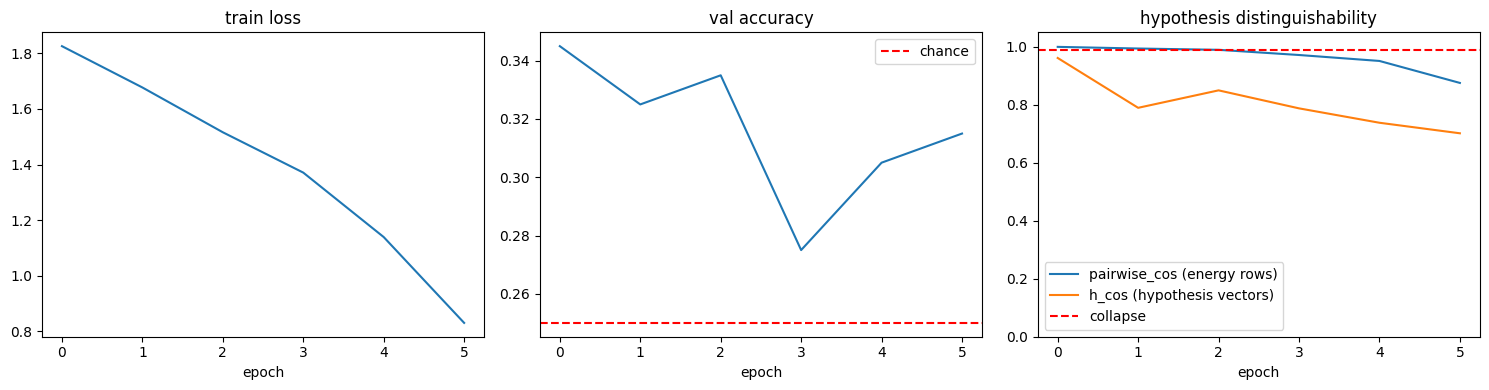

best val acc : 0.3450   (chance = 0.2500)
final pairwise_cos : 0.8755
final h_cos        : 0.7018


In [22]:
import matplotlib.pyplot as plt

EXPORT_DIR = "./exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history["loss"]);  ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["acc"]);   ax[1].axhline(0.25, ls="--", c="r", label="chance")
ax[1].set_title("val accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot(history["pairwise_cos"], label="pairwise_cos (energy rows)")
ax[2].plot(history["h_cos"], label="h_cos (hypothesis vectors)")
ax[2].axhline(0.99, ls="--", c="r", label="collapse")
ax[2].set_ylim(0, 1.05); ax[2].set_title("hypothesis distinguishability")
ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/{RUN_NAME}_curves.png", bbox_inches="tight")
plt.show()

print(f"best val acc : {history['best_acc']:.4f}   (chance = 0.2500)")
print(f"final pairwise_cos : {history['pairwise_cos'][-1]:.4f}")
print(f"final h_cos        : {history['h_cos'][-1]:.4f}")

<a id="8"></a>
## 8. Evaluation

Reload the **best** checkpoint rather than evaluating whatever weights
the last epoch happened to leave behind.

In [23]:
best_path = os.path.join(CKPT_DIR, f"{RUN_NAME}_best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device)["model"])
    print(f"[LOADED] {best_path}")

eval_model = model
metrics = evaluate(eval_model, val_loader, device)

for k, v in metrics.items():
    print(f"  {k:15s}: {v:.4f}")

print(f"\n  n = {len(val_ds)} examples, so the standard error is roughly "
      f"{(0.25*0.75/len(val_ds))**0.5:.3f} -- treat this accuracy as "
      f"'above chance or not', nothing finer.")

[LOADED] ./ckpt\qair_v44_best.pt


  acc            : 0.3450
  spread         : 0.0012
  entropy        : 1.3831
  diversity      : 0.0008
  collapse_peak  : 0.2586
  pairwise_cos   : 0.9999
  h_cos          : 0.9615

  n = 200 examples, so the standard error is roughly 0.031 -- treat this accuracy as 'above chance or not', nothing finer.


<a id="9"></a>
## 9. ⭐ Input ablation — does the model actually use its hypotheses?

**The most important cell in this notebook.**

qAIR claims to reason over multiple hypotheses held in superposition.
That claim is falsifiable in one line: corrupt the hypotheses and see
whether the answer changes. Pre-v44 it did not — not "changed a little",
but **bit-identically unchanged** at 294/869 under every corruption
tried:

```
intact H, O                   294/869 = 0.3383
H := zeros                    294/869 = 0.3383
H := gaussian noise           294/869 = 0.3383
H shuffled within sample      294/869 = 0.3383
H from a DIFFERENT question   294/869 = 0.3383
H := O (option echo)          294/869 = 0.3383
O := zeros                    223/869 = 0.2566   ← only O ever mattered
```

Accuracy alone could never have shown that. **If this reports FAIL, no
number in this notebook supports any claim about superposition, collapse,
or quantum reasoning** — however good it looks.

In [24]:
from evaluation.input_ablation import input_ablation, report

ab_results = input_ablation(eval_model, val_loader, device)
passed = report(ab_results)


INPUT ABLATION -- does the model actually use its hypotheses?
  intact                       0.3450   delta=+0.0000
  H := zeros                   0.3500   delta=+0.0050
  H := noise                   0.3550   delta=+0.0100
  H shuffled within sample     0.3450   delta=+0.0000   <-- IDENTICAL: H is unused
  H rolled across batch        0.3600   delta=+0.0150
  H := O                       0.3450   delta=+0.0000   <-- IDENTICAL: H is unused
  O := zeros                   0.2300   delta=-0.1150
--------------------------------------------------------------------
VERDICT: FAIL. Corrupting the hypotheses costs at most -0.0000 accuracy. The multi-hypothesis mechanism is inert; this model is an option-prior classifier. Do not report quantum, collapse, or superposition results from this checkpoint.


<a id="10"></a>
## 10. Reference baselines

Two numbers that decide how to read everything above.

**Data ceiling** — probes straight on the cached embeddings. No
architecture over this cache can do much better, so a qAIR number below
these is a problem with qAIR, not with the task. Measured pre-fix on the
full validation split:

| probe | val acc |
|---|---|
| O only | 0.3585 |
| diag(H_n, O_n) | 0.3527 |
| full pairwise H_k × O_n | 0.3979 |
| **Q × O pairwise** | **0.4849** |
| Q × O + H | 0.4408 ← the old `H` made it *worse* |

The full 8.2M-parameter pre-fix model scored **0.3383** — below the
options-only MLP.

**Direct LLM** — scores each option's likelihood under Qwen2.5-0.5B, the
same model that generated the hypotheses. If the pipeline cannot beat the
model it is built on top of, it is a lossy compression of knowledge the
generator already had. **This is the first thing a reviewer will check.**

In [25]:
from evaluation.baselines import run_probes

probe_results = run_probes(
    CACHE_DIR, train_samples=TRAIN_SAMPLES, val_samples=VAL_SAMPLES,
)

[CACHE FOUND] ./cache\arc_train.pt
[CACHE LOADED] 800 samples (complete=False, version=33)
[CACHE TRUNCATED TO max_samples] 800 samples
[CACHE QUALITY train] fallback hypotheses 0/3200 = 0.0%   fully-fallback samples 0/800
[CACHE FOUND] ./cache\arc_validation.pt
[CACHE LOADED] 200 samples (complete=False, version=33)
[CACHE TRUNCATED TO max_samples] 200 samples
[CACHE QUALITY validation] fallback hypotheses 1/798 = 0.1%   fully-fallback samples 0/200

train=798  val=198  chance=0.2500

=== DATA CEILING (probes on cached embeddings) ===
[SEED] Set to 0 (deterministic=False)
  O only                       val acc = 0.3788
[SEED] Set to 0 (deterministic=False)
  diag(H_n, O_n)               val acc = 0.3384
[SEED] Set to 0 (deterministic=False)
  Q x O                        val acc = 0.4141
[SEED] Set to 0 (deterministic=False)
  Q x O + H                    val acc = 0.3687


In [26]:
from evaluation.baselines import run_direct

# limit=None scores every loaded validation sample. Set e.g. limit=100
# for a faster read.
direct_acc, direct_records = run_direct(
    CACHE_DIR, split="validation", limit=None, max_samples=VAL_SAMPLES,
)

print(f"\nqAIR   : {metrics['acc']:.4f}")
print(f"direct : {direct_acc:.4f}")
print("\n" + ("qAIR beats its own generator." if metrics["acc"] > direct_acc
              else "*** The generator alone beats the full pipeline. ***"))

[CACHE FOUND] ./cache\arc_validation.pt
[CACHE LOADED] 200 samples (complete=False, version=33)
[CACHE TRUNCATED TO max_samples] 200 samples
[CACHE QUALITY validation] fallback hypotheses 1/798 = 0.1%   fully-fallback samples 0/200


Qwen/Qwen2.5-0.5B-Instruct direct: 100%|██████████| 200/200 [02:56<00:00,  1.13it/s]


=== DIRECT LLM BASELINE (Qwen/Qwen2.5-0.5B-Instruct, validation) ===
  length-normalized option likelihood : 0.3200  (64/200)

  If this beats the trained qAIR pipeline, the architecture is a
  lossy compression of knowledge the generator already had. That is
  the first thing a reviewer will check.

qAIR   : 0.3450
direct : 0.3200

qAIR beats its own generator.


<a id="11"></a>
## 11. Ablation grid

> ### ⚠️ Off by default — this is 40 training runs
> `run_ablation_suite` sweeps every config in `ABLATIONS` (8) against
> every seed in `config.SEEDS` (5). On CPU, with the quantum layer
> running twice per forward, that is **days**. Flip `RUN_GRID` only when
> you can afford it — ideally on a GPU.

The load-bearing comparison is **`A1b_quantum_only` vs
`A1c_classical_control_only`**. `ClassicalControlLayer` reproduces the
quantum layer's entire surrounding architecture — same compress/expand
widths, same fusion gate, same correction and energy heads, same input
squashing — and swaps *only* the PennyLane circuit for a classical MLP at
the circuit's measurement width. Total parameters match to within a
fraction of a percent (the circuit is 54 of ~1.12M), so a gap cannot be
blamed on capacity. It is the circuit, or it is nothing.

Single-run numbers are not interpretable: even the full 869-example
validation split gives a standard error of ~1.6 points, larger than most
gaps this grid produces. Hence multi-seed + the paired tests in §12.

In [27]:
from training.ablations import run_ablation_suite, ABLATIONS

RUN_GRID = False        # ⚠️ True = 8 configs x N seeds of training

print("configs in the grid:")
for name, cfg in ABLATIONS.items():
    print(f"  {name:<34s} {cfg}")

if RUN_GRID:
    ablation_results = run_ablation_suite(
        cache_dir=CACHE_DIR, ckpt_dir=CKPT_DIR,
        epochs=EPOCHS, patience=PATIENCE, n_qubits=n_qubits,
        seeds=(SEED,),          # start with one seed
        with_test=False,        # no test cache built at these caps
    )
else:
    ablation_results = None
    print("\nSkipped (RUN_GRID=False).")

configs in the grid:
  A0_no_question                     {'use_quantum': False, 'use_validator': False, 'persistent_steps': 3, 'use_question': False}
  A1_baseline                        {'use_quantum': False, 'use_validator': False, 'persistent_steps': 3}
  A1b_quantum_only                   {'use_quantum': True, 'use_validator': False, 'persistent_steps': 3}
  A1c_classical_control_only         {'backend': 'classical_control', 'use_validator': False, 'persistent_steps': 3}
  A2_validator                       {'use_quantum': False, 'use_validator': True, 'persistent_steps': 3}
  A3_persistent                      {'use_quantum': True, 'use_validator': True, 'persistent_steps': 3}
  A3c_classical_control_persistent   {'backend': 'classical_control', 'use_validator': True, 'persistent_steps': 3}
  A4_full_hybrid                     {'use_quantum': True, 'use_validator': True, 'persistent_steps': 5}

Skipped (RUN_GRID=False).


<a id="12"></a>
## 12. Statistics

Bootstrap CIs plus **paired** McNemar tests. Paired matters: two arms see
the same examples, so testing the disagreement cells is far more powerful
than comparing two independent proportions.

In [28]:
from evaluation.stats import compare_arms, bootstrap_ci

if ablation_results:
    compare_arms(ablation_results, baseline="A1_baseline")
else:
    print("No grid results -- run §11 with RUN_GRID=True first.\n")

_, recs = evaluate(eval_model, val_loader, device, return_records=True)
acc, lo, hi = bootstrap_ci(recs)
print(f"{RUN_NAME}: acc={acc:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
print(f"chance = 0.2500 -- {'ABOVE' if lo > 0.25 else 'NOT distinguishable from'} chance.")

No grid results -- run §11 with RUN_GRID=True first.



qair_v44: acc=0.3450  95% CI [0.2800, 0.4100]
chance = 0.2500 -- ABOVE chance.


<a id="13"></a>
## 13. Visualisation

`keep_trajectory` is off during training (it forced a device→host sync on
every reasoning step of every forward pass). Enabled just for this pass.

In [29]:
eval_model.reasoner.keep_trajectory = True

viz_loader = DataLoader(val_ds, batch_size=1, shuffle=True,
                        collate_fn=partial(collate_fn, shuffle_options=False))
vb = next(iter(viz_loader))

with torch.no_grad():
    viz = eval_model(
        vb["H"].to(device), vb["O"].to(device), Q=vb["Q"].to(device),
        H_mask=vb["H_mask"].to(device), O_mask=vb["O_mask"].to(device),
    )

eval_model.reasoner.keep_trajectory = False

probs = viz["collapse_probs"][0].cpu().numpy()
print("collapse_probs:", probs.round(4))
print(f"uniform would be {1/len(probs):.4f} -- "
      f"{'DEGENERATE' if abs(probs.max() - 1/len(probs)) < 0.01 else 'non-uniform, good'}")

collapse_probs: [0.2466 0.2489 0.2485 0.256 ]
uniform would be 0.2500 -- DEGENERATE


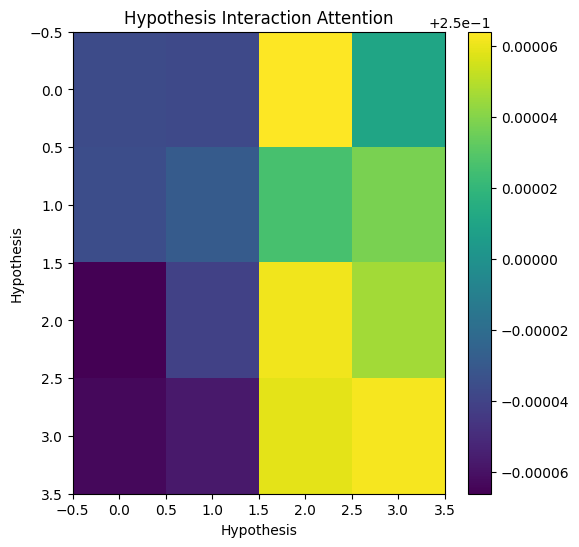

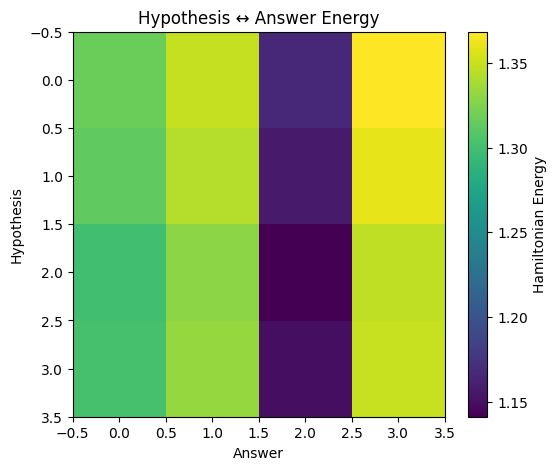

In [30]:
from visualization.attention_maps import plot_attention_map
from visualization.energy_maps import plot_energy_map

att = viz["attention"]
att = att[0, 0] if att.dim() == 4 else att[0]
plot_attention_map(att, save_path=f"{EXPORT_DIR}/{RUN_NAME}_attention.png")
plot_energy_map(viz["answer_energy"][0], save_path=f"{EXPORT_DIR}/{RUN_NAME}_energy.png")

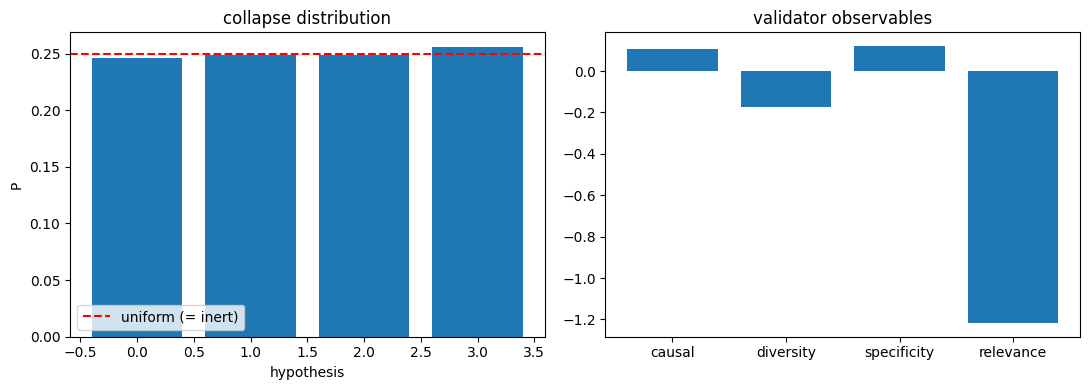

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(len(probs)), probs)
ax[0].axhline(1 / len(probs), ls="--", c="r", label="uniform (= inert)")
ax[0].set_xlabel("hypothesis"); ax[0].set_ylabel("P"); ax[0].legend()
ax[0].set_title("collapse distribution")

v = viz["validator"]
if v is not None:
    names = ["causal", "diversity", "specificity", "relevance"]
    ax[1].bar(names, [v[n][0].mean().item() for n in names])
    ax[1].set_title("validator observables")
plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/{RUN_NAME}_collapse.png", bbox_inches="tight")
plt.show()

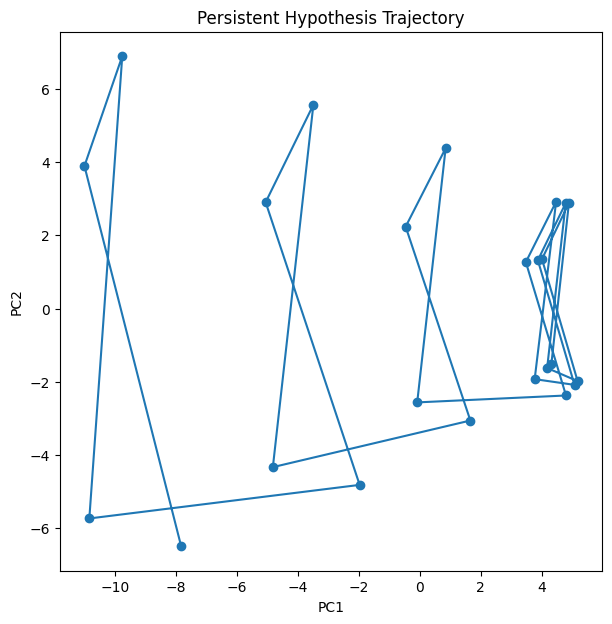

In [32]:
from visualization.trajectory import plot_trajectory

if viz["trajectory"]:
    plot_trajectory(viz["trajectory"], save_path=f"{EXPORT_DIR}/{RUN_NAME}_trajectory.png")
else:
    print("no trajectory captured")

<a id="14"></a>
## 14. Summary

Reads the run back and states plainly what it does and does not support.

In [33]:
print("=" * 68)
print(f"qAIR-vNext v44  --  {RUN_NAME}")
print("=" * 68)
print(f"data          : {len(train_ds)} train / {len(val_ds)} val  (capped)")
print(f"backend       : {model.backend}   question={model.use_question}"
      f"   feedback={model.validator_feedback}")
print(f"parameters    : {total:,}  (circuit {circuit:,})")
print()
print(f"val accuracy  : {metrics['acc']:.4f}   [95% CI {lo:.4f}, {hi:.4f}]")
print(f"chance        : 0.2500")
print(f"direct LLM    : {direct_acc:.4f}" if 'direct_acc' in dir() else "direct LLM    : not run")
print()
print(f"pairwise_cos  : {metrics['pairwise_cos']:.4f}  (1.0 = inert)")
print(f"h_cos         : {metrics['h_cos']:.4f}")
print(f"collapse_peak : {metrics['collapse_peak']:.4f}  (1/K = uniform = inert)")
print()
print(f"input ablation: {'PASS -- hypotheses matter' if passed else 'FAIL -- hypotheses unused'}")
print("=" * 68)

if not passed:
    print(
        "\nThe multi-hypothesis mechanism is inert in this run.\n"
        "Report nothing about superposition, collapse or quantum reasoning\n"
        "from this checkpoint. Check the cache fallback rate first (§3b),\n"
        "then h_cos vs pairwise_cos above to tell reasoner-collapse from\n"
        "selector-indifference."
    )
elif lo <= 0.25:
    print("\nAccuracy is not distinguishable from chance at this sample size.")

qAIR-vNext v44  --  qair_v44
data          : 800 train / 200 val  (capped)
backend       : quantum   question=True   feedback=True
parameters    : 10,578,677  (circuit 54)

val accuracy  : 0.3450   [95% CI 0.2800, 0.4100]
chance        : 0.2500
direct LLM    : 0.3200

pairwise_cos  : 0.9999  (1.0 = inert)
h_cos         : 0.9615
collapse_peak : 0.2586  (1/K = uniform = inert)

input ablation: FAIL -- hypotheses unused

The multi-hypothesis mechanism is inert in this run.
Report nothing about superposition, collapse or quantum reasoning
from this checkpoint. Check the cache fallback rate first (§3b),
then h_cos vs pairwise_cos above to tell reasoner-collapse from
selector-indifference.


---

### Next steps

1. **Scale the cache up.** 800/200 answers "does it work", not "how well".
   ```bash
   python scripts/build_cache.py --splits train validation
   ```
2. **Build the test split** — validation currently does double duty as
   both model selection and reported metric, which biases it upward.
3. **Run the grid** (§11) with multiple seeds, on a GPU.
4. **Complex amplitudes.** With real, non-negative amplitudes the
   Born-rule step is *algebraically identical* to `softmax(−E/T)`
   (verified to fp32 epsilon). Until interference cross-terms
   `2·Re(aᵢ·conj(aⱼ))` actually contribute, it is notation rather than
   physics — and a write-up must say so.